# Image Classification using CNN

This project uses a Convolutional Neural Network (CNN) to classify images from the CIFAR-10 dataset into ten different object categories.

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.cifar10.load_data()

print("Training Images :",x_train.shape)
print("Testing Images :",x_test.shape)

Training Images : (50000, 32, 32, 3)
Testing Images : (10000, 32, 32, 3)


In [18]:
x_train=x_train.astype("float32")/255.0
x_test=x_test.astype("float32")/255.0

In [19]:
class_names=[
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

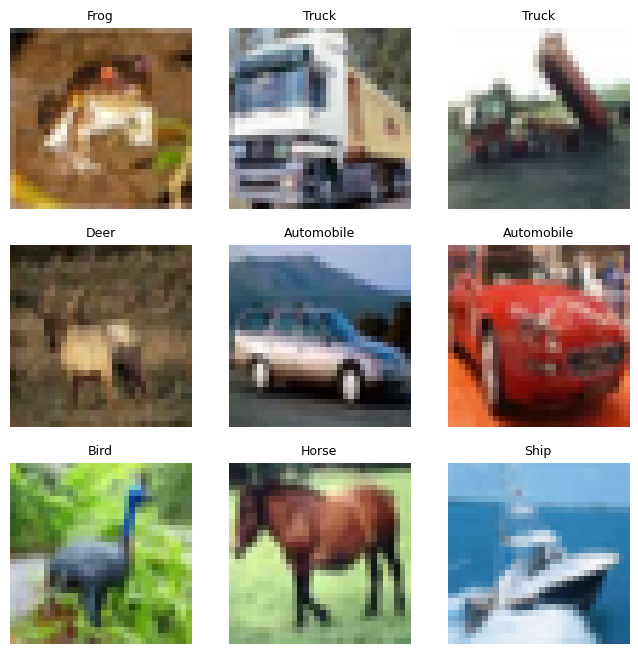

In [20]:
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]],fontsize=9)
    plt.axis("off")

plt.show()

In [21]:
model=Sequential()

model.add(Conv2D(32,(3,3),padding="same",activation="relu",input_shape=(32,32,3)))
model.add(BatchNormalization())

model.add(Conv2D(32,(3,3),activation="relu"))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
model.add(BatchNormalization())

model.add(Conv2D(64,(3,3),activation="relu"))
model.add(MaxPooling2D())
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(256,activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(10,activation="softmax"))

In [22]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,602 (2.51 MB)

 Trainable params: 658,410 (2.51 MB)

 Non-trainable params: 192 (768.00 B)

In [23]:
early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [24]:
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 132s 207ms/step - accuracy: 0.3561 - loss: 1.7496 - val_accuracy: 0.3433 - val_loss: 1.8791
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 206ms/step - accuracy: 0.4998 - loss: 1.3760 - val_accuracy: 0.6024 - val_loss: 1.0995
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 144s 209ms/step - accuracy: 0.5900 - loss: 1.1674 - val_accuracy: 0.6363 - val_loss: 1.0295
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 129s 207ms/step - accuracy: 0.6340 - loss: 1.0401 - val_accuracy: 0.6780 - val_loss: 0.9154
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 118s 189ms/step - accuracy: 0.6694 - loss: 0.9467 - val_accuracy: 0.6904 - val_loss: 0.8795
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.6928 - loss: 0.8875 - val_accuracy: 0.7064 - val_loss: 0.8512
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 203ms/step - accuracy: 0.7124 - loss: 0.8345 - val_accuracy: 0.7439 - val_loss: 0.7386
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 128s 205ms/step - accuracy: 0.7257 -

In [25]:
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy :", round(accuracy*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7900 - loss: 0.6463
Test Accuracy : 79.0 %


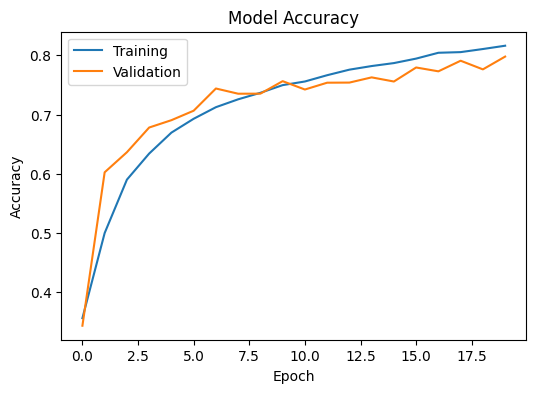

In [26]:
plt.figure(figsize=(6,4))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training","Validation"])

plt.show()

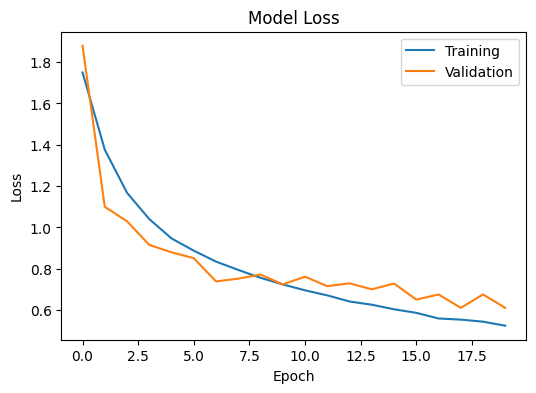

In [27]:
plt.figure(figsize=(6,4))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training","Validation"])

plt.show()

Actual : Bird
Predicted : Bird


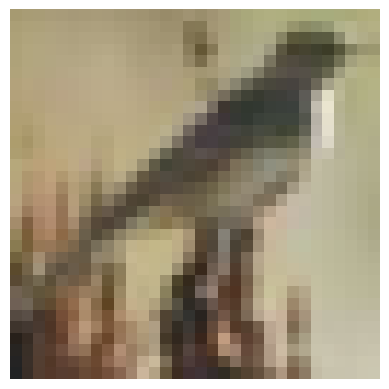

In [28]:
index = np.random.randint(0, len(x_test))

prediction = model.predict(
    x_test[index].reshape(1,32,32,3),
    verbose=0
)

predicted = np.argmax(prediction)

plt.imshow(x_test[index])
plt.axis("off")

print("Actual :", class_names[y_test[index][0]])
print("Predicted :", class_names[predicted])

In [29]:
model.save("Image_Classification_CNN.keras")

print("Model saved successfully.")

Model saved successfully.


## Conclusion

A Convolutional Neural Network (CNN) was trained on the CIFAR-10 dataset to classify images into ten different categories. The model learned meaningful visual features and achieved good classification performance, demonstrating the effectiveness of CNNs for image classification tasks.